In [1]:
# from LadrunoGraphStyle import set_default_plot_params, main_colors
# set_default_plot_params()

In [2]:
from fem import (
    # Core
    Material,
    # Sections
    Membrane,
    # Gmsh tools
    GMSHtools,
    # FEM builders
    plan, build_load_vector,
    # Plotting — matplotlib
    plot_gmsh_mesh,
    # Units
    kgf, tf, kN, MPa, GPa, kg, g, cm, m,
    # Parameters
    globalParameters,
)

import os
import numpy as np
import matplotlib.pyplot as plt
import gmsh

np.set_printoptions(suppress=True, precision=6, linewidth=400)


  FEM -- Finite Element Method for Structural Analysis
  Based on the course by Prof. José Abell

  Version 0.1.0                        © 2026 All Rights Reserved

  Repository  :  https://github.com/ppalacios92/FEM
  Web Book    :  https://books.nmorabowen.com/books/fem

  Patricio Palacios B.    |    Nicolas Mora Bowen

  ********* (>'-')> Ladruño4ever  *********



In [3]:
# General model parameters

output_path = os.getcwd()
mesh_name = 'batman'
output_file = os.path.join(output_path, mesh_name + '.msh')

if not os.path.exists(output_path):
    os.makedirs(output_path)

In [4]:
# Material
Steel=Material( name='Steel',
                E=2000,
                nu=0.30,
                rho=1.25*tf/m**3*0)

# Sections
F1=Membrane(    name='F1',
                thickness=15,
                material=Steel)

# Dictionaries
section_dictionary={17:F1,
                        }

restrain_dictionary={18:['r', 'f']}

load_dictionary = {
                19:   {'value': 100, 'direction': 'x'},   
                20:   {'value': 100, 'direction': '-x'},   

}

In [5]:
# Read mesh
mesh = GMSHtools(output_file)
node_map, system_nDof = plan(mesh, restrain_dictionary)


  MESH SUMMARY

  === NODES ===  (2681 total — showing first 3)
     Tag              x              y              z
--------------------------------------------------------------------------------
       1        -1.0000         1.0000         0.0000
       2        -0.7500         3.0000         0.0000
       3        -0.5000         2.2500         0.0000
--------------------------------------------------------------------------------

  === PHYSICAL GROUPS ===  (4 total)
      ID    Dim   Name
--------------------------------------------------------------------------------
      18      0   'support'
      19      1   'load_p_x'
      20      1   'load_m_x'
      17      2   'steel'
--------------------------------------------------------------------------------

  === ELEMENTS ===  (4 groups)
      ID    Dim     Type   Nodes/el   N elements   Name
--------------------------------------------------------------------------------
      18      0       15          1            2   'su

In [6]:
# # Read raw mesh data from gmsh file
# mesh = read_mesh(output_file)

# # Instantiate Node objects and apply boundary conditions
# node_map, nodes, system_nDof = build_nodes(mesh, restrain_dictionary)

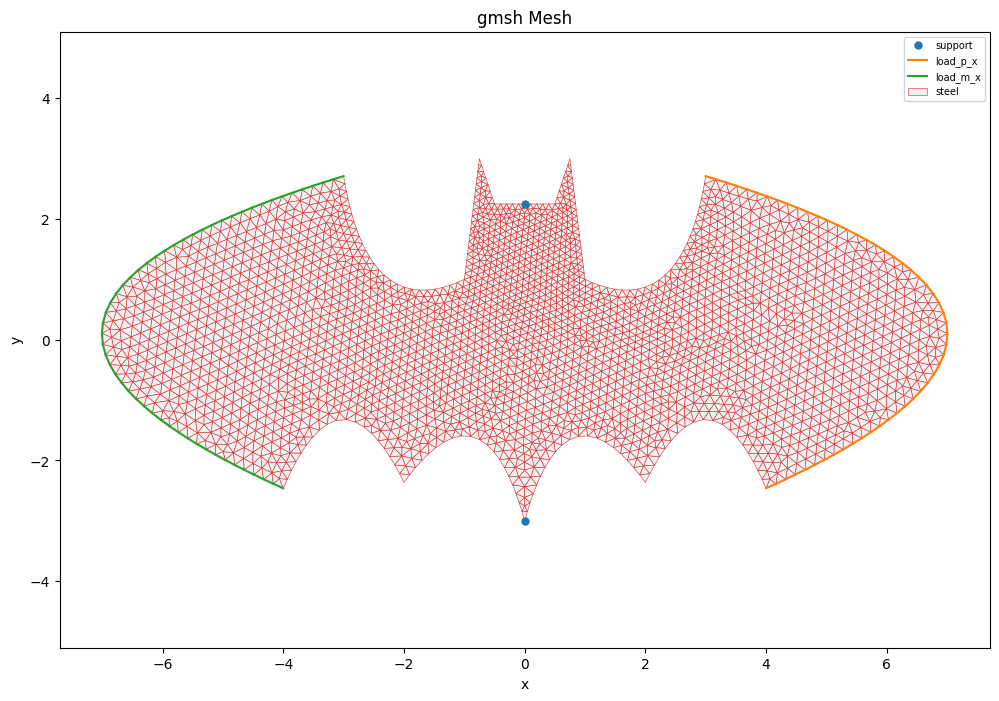

In [7]:
# %matplotlib widge
plot_gmsh_mesh(mesh,
               show_node_labels   = False,
               show_element_labels= False,
               show_node_points   = False,
            #    view_3d            = True,   elev= 45, azim= -45,
               figsize            = (12, 8))

In [8]:
# Load vector
F_load = build_load_vector(mesh            = mesh,
                           node_map        = node_map,
                           load_dictionary = load_dictionary,
                           system_nDof     = system_nDof)

## Opensees

In [9]:
# import openseespy.opensees as ops
import opensees as ops
import opsvis as opsv

ops.wipe()
ops.model('basicBuilder','-ndm',2,'-ndf',2)



         OpenSees -- Open System For Earthquake Engineering Simulation
                 Pacific Earthquake Engineering Research Center
                        Version 3.7.2 64-Bit


      (c) Copyright 1999-2016 The Regents of the University of California
                              All Rights Reserved
  (Copyright and Disclaimer @ http://www.berkeley.edu/OpenSees/copyright.html)


  *********** (o_O) OPENSEES (>'-')> Ladruno4ever *********** 3.7.2




In [10]:
# Nodes
for tag, (x, y, z) in mesh.nodes.items():
    ops.node(tag, x, y)

In [11]:
# Boundary conditions
for phys_id, condition in restrain_dictionary.items():
    if phys_id not in mesh.elements:
        continue
    for conn in mesh.elements[phys_id]['connectivity']:
        for tag in conn:
            ops.fix(tag, *[1 if r == 'r' else 0 for r in condition])

In [12]:
# Material
solidMaterialTag = 1

ops.nDMaterial('ElasticIsotropic', solidMaterialTag,
               Steel.E,
               Steel.nu,
               Steel.rho)

In [13]:
# Elements
for phys_id, section in section_dictionary.items():
    if phys_id not in mesh.elements:
        continue
    group = mesh.elements[phys_id]
    for elem_tag, conn in zip(group['element_tags'], group['connectivity']):
        ops.element('tri31', elem_tag, *conn, section.thickness, 'PlaneStress', solidMaterialTag)

Tri31 - Written by Roozbeh G. Mikola and N.Sitar, UC Berkeley


<Axes: >

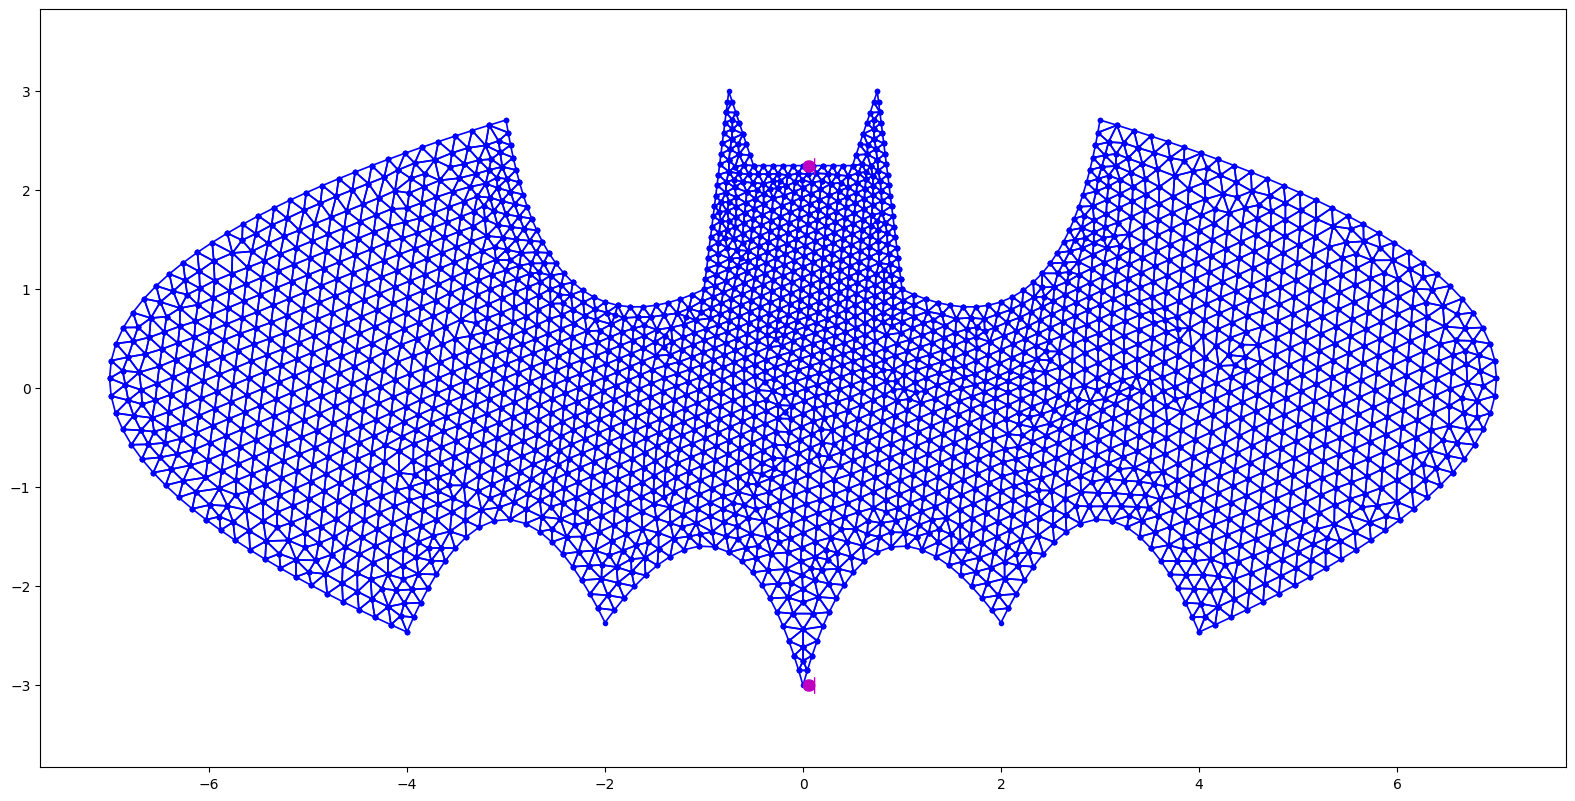

In [14]:
opsv.plot_model(node_labels=0, element_labels=0, fig_wi_he=(50,25))

In [15]:
# Loads
ts_tag      = 2
pattern_tag = 2
ops.timeSeries('Linear', ts_tag)
ops.pattern('Plain', pattern_tag, ts_tag)

for node in node_map.values():
    fx = F_load[node.idx[0]]
    fy = F_load[node.idx[1]]
    if abs(fx) > 0 or abs(fy) > 0:
        ops.load(int(node.name), float(fx), float(fy))

In [16]:
NstepGravity=10
DGravity=1/NstepGravity

ops.system("FullGeneral")
ops.numberer("Plain")
ops.constraints("Plain")
ops.integrator("LoadControl", DGravity )
ops.test("NormUnbalance", 1.0e-6, 100 , 0)
ops.algorithm("Newton")
ops.analysis("Static")

ops.analyze(NstepGravity)

0

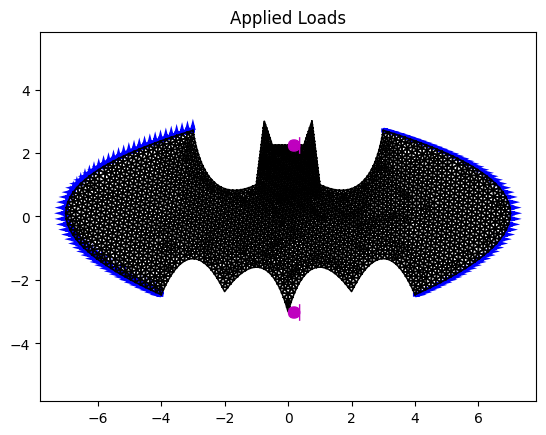

In [17]:
opsv.plot_loads_2d(sfac=0.1)
for txt in plt.gca().texts:
    txt.set_visible(False)
plt.title('Applied Loads')
plt.show()

10

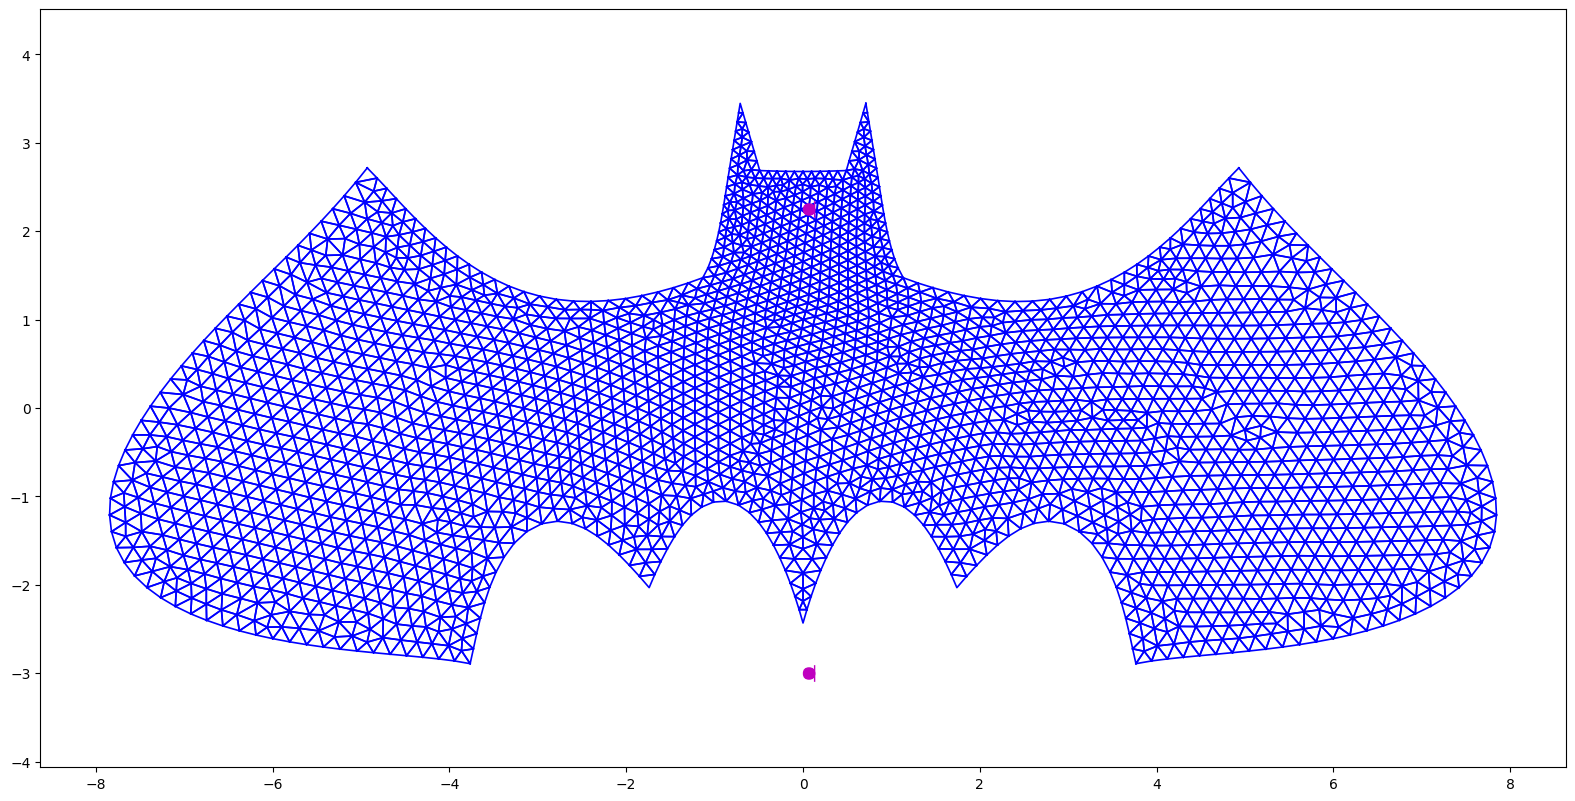

In [18]:
opsv.plot_defo(
    sfac=10,
    fig_wi_he=(50, 25),
    endDispFlag=True,
    unDefoFlag=0
)

Text(0.5, 1.0, 'syy')

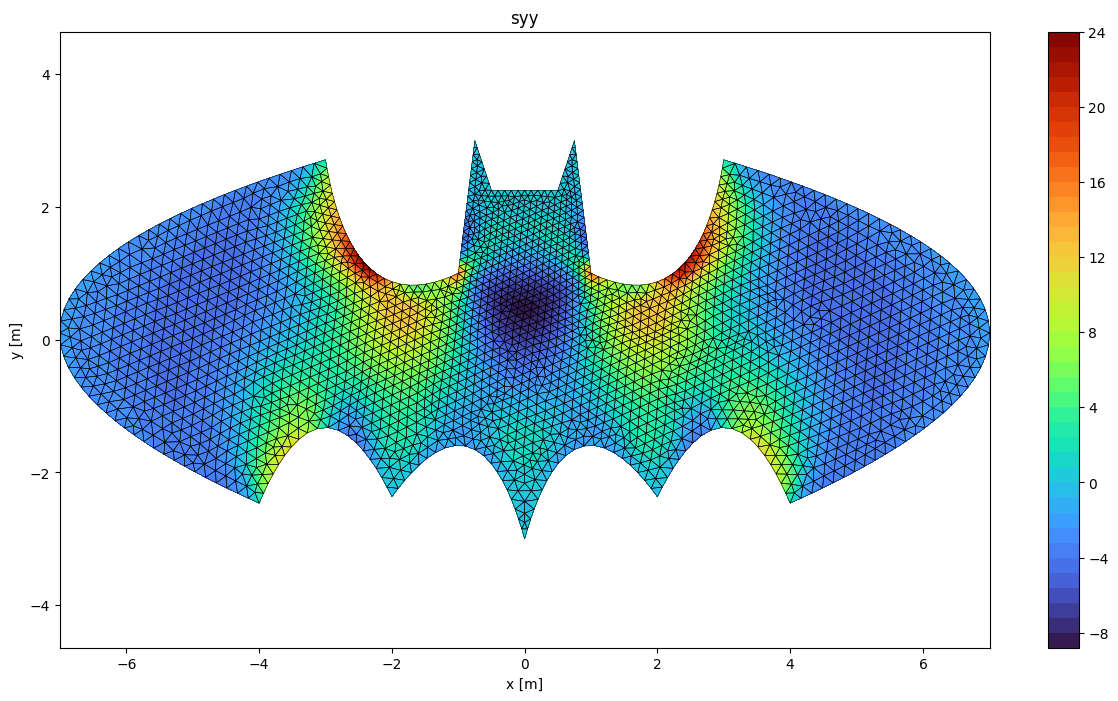

In [19]:
# jstr = 'sxx'
jstr = 'syy'
# jstr = 'sxy'
# jstr = 'vmis'
# jstr = 's1'
# jstr = 's2'
# jstr = 'angle'

plt.figure(figsize=(15, 8))
opsv.plot_stress(jstr)
plt.xlabel('x [m]')
plt.ylabel('y [m]')
plt.title(f'{jstr}')